In [1]:
#imports

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort
import onnx
from onnx import version_converter
import torch

ort.get_device()

'GPU'

In [2]:
# config
MODELS_PATH = Path("../saved_models/cvpr_games_oct_30_onnx/") # relative to ipynb
IMAGES_PATH = Path("../data/objects365_val_patch1/") # relative to ipynb

BASELINE_PATH = Path("baseline.onnx") # converted to higher opset

# pick a model to measure
some_model = MODELS_PATH/"Sat_Oct_28_18_44_34_2023_starry_night_1_1E05_1E10_1E03.onnx"
torch_model_path = Path("../saved_models/cvpr_games_oct_30/Sat_Oct_28_18_44_34_2023_starry_night_1_1E05_1E10_1E03.pth")

# basic optimisations
OPTIMISED_PATH = Path("optimised.onnx")
FP16_PATH = Path("baseline_fp16.onnx")
IDENTITYNET_PATH = Path("identity.onnx")

# quantization (very slow)
QUANTIZED_PATH = Path("quantized_int8.onnx")

# distilations
RES2_PATH = Path("transformerNetFusion_res2.onnx")
RES1_PATH = Path("transformerNetFusion_res1.onnx")
SEPARATED_PATH = Path("transformerNetFusion_separated.onnx")
SEPARATED_2xSCALED_PATH = Path("transformerNetFusion_separated_2xscaled.onnx")
SEPARATED_4xSCALED_PATH = Path("transformerNetFusion_separated_4xscaled.onnx")

input_shape = (1,3,640,640) # checked beforehand

if not any(MODELS_PATH.glob("*.onnx")):
    raise RuntimeError("Models not found, you didn't clone the GBGST repo or sometthing is very wrong")


PROVIDERS = ["CUDAExecutionProvider"] # dont use tensorrt, or don't try to measure on CPU

In [3]:
def stylize_and_display_image(image_path: Path, model_path: Path, dtype=np.float32):
    print("showing",image_path)
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (640, 640))
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    input_tensor = image.astype(dtype)
    input_tensor = np.transpose(input_tensor, (2,0,1)) # HWC to CHW
    input_tensor = np.expand_dims(input_tensor, axis=0) # add batch dim
    input_name = "input"
    ort_sess = ort.InferenceSession(model_path, providers=PROVIDERS)
    outputs = ort_sess.run(None, {input_name: input_tensor})
    output_tensor = outputs[0]
    print("Output shape:", output_tensor.shape)
    # display output as image
    output_image = np.squeeze(output_tensor, axis=0) # remove batch dim
    output_image = np.transpose(output_image, (1,2,0)) # CHW to
    output_image = np.clip(output_image, 0, 255).astype(np.uint8)
    plt.imshow(output_image)
    plt.axis('off')
    plt.show()

Stylising and displaying image with model: transformerNetFusion_res2_distilled_fp16.onnx
showing ../data/objects365_val_patch1/objects365_v1_00045989.jpg


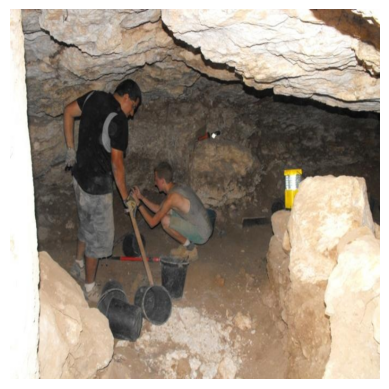

Output shape: (1, 3, 640, 640)


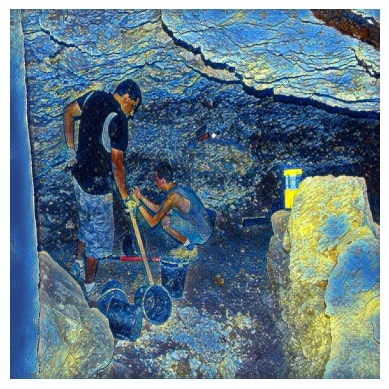

Stylising and displaying image with model: transformerNetFusion_separated_2xscaled_distilled.onnx
showing ../data/objects365_val_patch1/objects365_v1_00045989.jpg


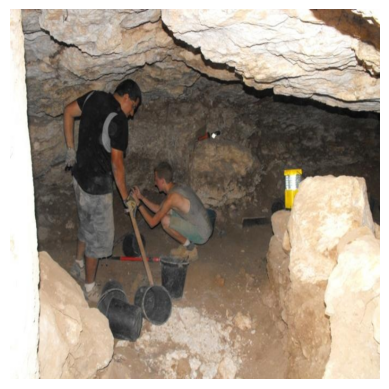

2026-02-11 20:52:56.754109857 [E:onnxruntime:, inference_session.cc:2544 operator()] Exception during initialization: filesystem error: cannot get file size: No such file or directory [./transformerNetFusion_separated_2xscaled_distilled.onnx.data]


RuntimeException: [ONNXRuntimeError] : 6 : RUNTIME_EXCEPTION : Exception during initialization: filesystem error: cannot get file size: No such file or directory [./transformerNetFusion_separated_2xscaled_distilled.onnx.data]

In [4]:
for model in Path(".").glob("transformer*dist*.onnx"):
    dtype = np.float16 if "16" in model.stem else np.float32
    print("Stylising and displaying image with model:", model.name)
    stylize_and_display_image(IMAGES_PATH/"objects365_v1_00045989.jpg", model, dtype=dtype)